## 1. Imports

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import time

# from multiprocessing.dummy import Pool as ThreadPool
from concurrent.futures import ProcessPoolExecutor

## 2. Timeseries Data Simulation

### Simulate BDM

$$
dX_t = k  (\mu - X_t) dt + D \sqrt{X_t} dW_t
$$

Update rule : $X_{t + dt} = X_t + k(\mu - X_t)dt + D \sqrt{X_t} \eta$

In [28]:
def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]

In [29]:
def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

### Simulate SLM

$$
dX_t = k  X_t (\mu - X_t) dt + D X_t dW_t
$$

Update rule : $ X_{t + dt} = X_t + k X_t ( \mu - X_t) dt + D X_t \eta $

In [30]:
def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]

In [31]:
def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

### Wrapper Function

In [32]:
def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)

    return sim_data

### Simulation Parameters

In [33]:
MODEL = 'SLM'

In [34]:
X0 = 4.5
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

### Run simulation and visualize

In [35]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))

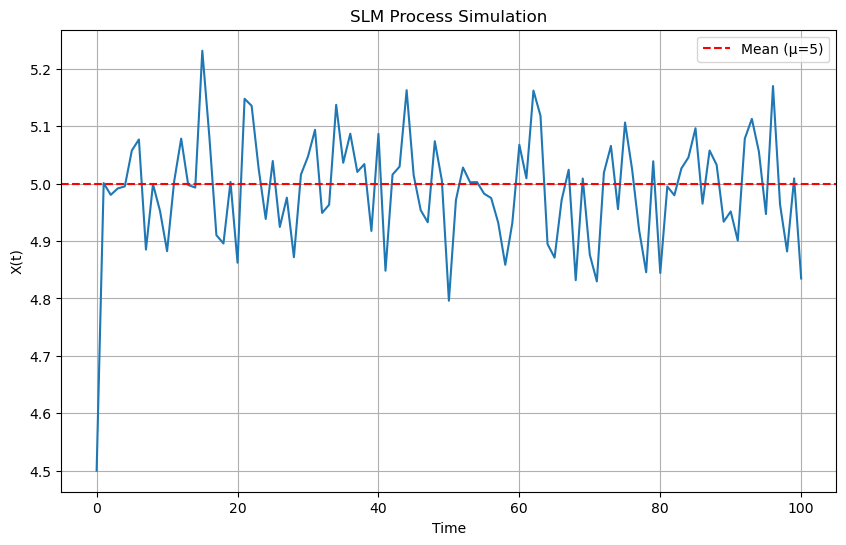

In [36]:
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

## 3. Lamperti transform of timeseries data

In [42]:
def BDM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result
    
def SLM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

## 4. Generating Wiener Bridges (OLD)

In [13]:
# Parameters
NB = 10000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

#T =  time series timespan
#eff_dt = timestep between datapoints (sampling)
#N = number of datapoints
datapoint_times = np.linspace(0, T, N)

# data = [1, 3, 5, 8, 12, 9 , 6, 8] #TO DELETE - X data
# datapoint_times = [0, 3, 5, 6, 9, 12, 15, 20] #TO DELETE - timepoints of data

In [22]:
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1):   
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B
    
def multibridge(NB, bridge_steps, data, datapoint_times, eff_dt):   
    all_bridges = np.empty((NB, 0), dtype=np.float32)  
    for datapoint_idx in range(len(data) - 1):
        x_i = data[datapoint_idx]
        x_f = data[datapoint_idx + 1]      
        B_segment = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)    
        # remove the first column to avoid repeated times for segments after the first one 
        if datapoint_idx > 0:
            B_segment = B_segment[:, 1:]
        all_bridges = np.concatenate((all_bridges, B_segment), axis=1)      
    return all_bridges

In [23]:
def bridge_adapter(args):
    return bridge(*args) # Unpacks the tuple into separate arguments for the bridge function

In [24]:
def parallel_multibridge(NB, bridge_steps, data, datapoint_times, eff_dt):
    all_bridges = np.empty((NB, 0), dtype=np.float32)    
    parameters = [(NB, bridge_steps, data[i], data[i + 1], Delta_t_B, D) for i in range(len(data) - 1)]    
    with ThreadPool() as pool:    # create a new thread pool that automatically gets cleaned up 
        results = pool.map(bridge_adapter, parameters)  # applies the function to all items in parallel using multiple threads    
    for i, B_segment in enumerate(results):   # gets index as well as element 
        if i > 0:
            B_segment = B_segment[:, 1:]
        all_bridges = np.concatenate((all_bridges, B_segment), axis=1)    
    return all_bridges

In [ ]:
start_time = time.time()

B_multi = multibridge(NB, bridge_steps, sim_data, datapoint_times, eff_dt)
plt.plot(B_multi.T)
plt.show()

# Record end time
end_time = time.time()

# Calculate and display duration
duration = end_time - start_time
print(f"Script took {duration:.4f} seconds to run")

In [ ]:
start_time = time.time()

B_parallel = parallel_multibridge(NB, bridge_steps, sim_data, datapoint_times, eff_dt)
plt.plot(B_parallel.T)
plt.show()

# Record end time
end_time = time.time()

# Calculate and display duration
duration = end_time - start_time
print(f"Script took {duration:.4f} seconds to run")

In [26]:
parameters = [(M, N, times[i], times[i + 1], nodes[i], nodes[i + 1]) for i in range(len(nodes) - 1)]

In [27]:
parameters

[(10000, 100, 0, 3, 1, 3),
 (10000, 100, 3, 5, 3, 5),
 (10000, 100, 5, 6, 5, 8),
 (10000, 100, 6, 9, 8, 12),
 (10000, 100, 9, 12, 12, 9),
 (10000, 100, 12, 15, 9, 6),
 (10000, 100, 15, 20, 6, 8)]

In [23]:
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1):   
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B
    
def multibridge(NB, bridge_steps, data, datapoint_times, eff_dt):   
    all_bridges = np.empty((NB, 0), dtype=np.float32)  
    for datapoint_idx in range(len(data) - 1):
        x_i = data[datapoint_idx]
        x_f = data[datapoint_idx + 1]      
        B_segment = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)    
        # remove the first column to avoid repeated times for segments after the first one 
        if datapoint_idx > 0:
            B_segment = B_segment[:, 1:]
        # all_bridges = np.concatenate((all_bridges, B_segment), axis=1)  
    del B_segment
    return "lmao"

def bridge_adapter(args):
    return bridge(*args) # Unpacks the tuple into separate arguments for the bridge function

def parallel_multibridge(NB, bridge_steps, data, datapoint_times, eff_dt):
    all_bridges = np.empty((NB, 0), dtype=np.float32)    
    parameters = [(NB, bridge_steps, data[i], data[i + 1], Delta_t_B, D) for i in range(len(data) - 1)]    
    with ThreadPool() as pool:    # create a new thread pool that automatically gets cleaned up 
        results = pool.map(bridge_adapter, parameters)  # applies the function to all items in parallel using multiple threads    
    for i, B_segment in enumerate(results):   # gets index as well as element 
        if i > 0:
            B_segment = B_segment[:, 1:]
        # all_bridges = np.concatenate((all_bridges, B_segment), axis=1)  
    del B_segment
    return "lmao"

In [25]:
start_time = time.time()

B_multi = multibridge(NB, bridge_steps, sim_data, datapoint_times, eff_dt)
# plt.plot(B_multi.T)
# plt.show()

# Record end time
end_time = time.time()

# Calculate and display duration
duration = end_time - start_time
print(f"Script took {duration:.4f} seconds to run")

Script took 18.6774 seconds to run


In [26]:
start_time = time.time()

B_multi = parallel_multibridge(NB, bridge_steps, sim_data, datapoint_times, eff_dt)
# plt.plot(B_multi.T)
# plt.show()

# Record end time
end_time = time.time()

# Calculate and display duration
duration = end_time - start_time
print(f"Script took {duration:.4f} seconds to run")

Script took 20.3121 seconds to run


In [28]:
print(B_multi)

lmao


In [30]:
from concurrent.futures import ProcessPoolExecutor

def parallel_multibridge(NB, bridge_steps, data, datapoint_times, eff_dt):
    all_bridges = np.empty((NB, 0), dtype=np.float32)    
    
    # Create parameters list
    parameters = [(NB, bridge_steps, data[i], data[i + 1], Delta_t_B, D) 
                  for i in range(len(data) - 1)]
    
    # Use ProcessPoolExecutor for CPU-bound tasks
    with ProcessPoolExecutor() as pool:
        results = pool.map(bridge_adapter, parameters)
    
    # Process results
    for i, B_segment in enumerate(results):
        if i > 0:
            B_segment = B_segment[:, 1:]
        # all_bridges = np.concatenate((all_bridges, B_segment), axis=1)
        
    return "lmao"

In [31]:
start_time = time.time()

B_multi = parallel_multibridge(NB, bridge_steps, sim_data, datapoint_times, eff_dt)
# plt.plot(B_multi.T)
# plt.show()

# Record end time
end_time = time.time()

# Calculate and display duration
duration = end_time - start_time
print(f"Script took {duration:.4f} seconds to run")

Script took 8.6629 seconds to run


## 4. Generating Wiener Bridges

In [16]:
# Parameters
NB = 10000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

In [18]:
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1):   
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B

## 5. Getting $\hat{I}$ from a bridge

In [37]:
#This is not necessary, but useful to keep.

def A_BDM(k, mu, x):
    return (2 * k * mu - 0.5 * k * x**2 - 0.5) / x

def A_SLM(k, mu, x):
    return k * (mu - np.exp(x) - 0.5)

In [38]:
def I_hat(k, mu, B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2)
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B) - 0.5))**2)

    return Ihat

## 6. Calculating Radon-Nikodym Derivative from Bridge Values

In [39]:
def RN_Derivative_BDM(B, k, mu, D):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, model='BDM')

    return np.exp(  
        ( 2 * k * mu * np.log(x_f/x_i) - 
          np.log(x_f/x_i) / 2 - 
          k * (x_f**2 - x_i**2) / 4 )/
        (D**2) -
        Ihat / ( 2 * (D**2) )
    )

def RN_Derivative_SLM(B, k, mu, D):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, model='SLM')

    return np.exp(
        (
            (k * mu - 0.5)*(x_f - x_i) - 
            k*(np.exp(x_f) - np.exp(x_i))
        ) / (D**2) - 
        Ihat / (2 * (D**2))
    )
    

In [40]:
def RN_Derivative(B, k, mu, D, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return RN_Derivative_BDM(B, k, mu, D)
    elif model == 'SLM':
        return RN_Derivative_SLM(B, k, mu, D)

In [43]:
print(RN_Derivative(SLM_Lamperti(sim_data), k, mu, D, model='SLM'))

0.0


In [44]:
print(I_hat(k, mu, sim_data, model='SLM'))

18757047.693167213
